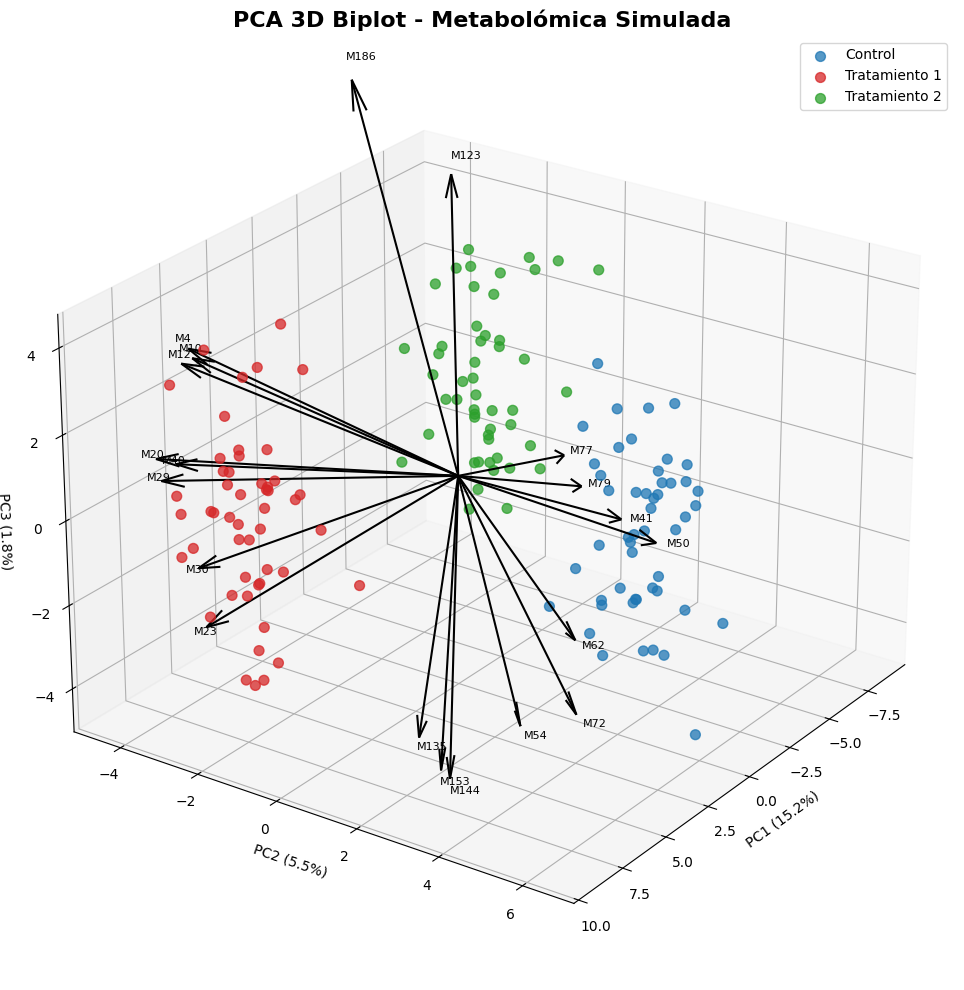

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# ==================================
# DATOS SIMULADOS DE METABOLÓMICA
# ==================================
np.random.seed(123)

n_grupos = 3
n_muestras_grupo = 50
n_metabolitos = 200

# Grupo Control
control = np.random.normal(0, 1, (n_muestras_grupo, n_metabolitos))

# Grupo Tratamiento 1
trat1 = np.random.normal(0, 1, (n_muestras_grupo, n_metabolitos))
trat1[:, :40] += 2

# Grupo Tratamiento 2
trat2 = np.random.normal(0, 1, (n_muestras_grupo, n_metabolitos))
trat2[:, 40:80] -= 2

X = np.vstack([control, trat1, trat2])

grupos = (
    ['Control'] * n_muestras_grupo +
    ['Tratamiento 1'] * n_muestras_grupo +
    ['Tratamiento 2'] * n_muestras_grupo
)

# ==================================
# ESCALADO
# ==================================
X_scaled = StandardScaler().fit_transform(X)

# ==================================
# PCA
# ==================================
pca = PCA(n_components=3)
scores = pca.fit_transform(X_scaled)

# Loadings
loadings = pca.components_.T

# ==================================
# SELECCIÓN DE METABOLITOS IMPORTANTES
# ==================================
magnitud = np.sqrt(
    loadings[:, 0]**2 +
    loadings[:, 1]**2 +
    loadings[:, 2]**2
)

top_n = 20
idx_top = np.argsort(magnitud)[-top_n:]

# ==================================
# GRAFICO 3D
# ==================================
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

colores = {
    'Control': '#1f77b4',
    'Tratamiento 1': '#d62728',
    'Tratamiento 2': '#2ca02c'
}

for grupo in np.unique(grupos):

    idx = np.array(grupos) == grupo

    ax.scatter(
        scores[idx,0],
        scores[idx,1],
        scores[idx,2],
        color=colores[grupo],
        s=50,
        alpha=0.75,
        label=grupo
    )

# ==================================
# FLECHAS DE LOADINGS
# ==================================

escala = 40

for i in idx_top:

    x = loadings[i,0] * escala
    y = loadings[i,1] * escala
    z = loadings[i,2] * escala

    ax.quiver(
        0, 0, 0,
        x, y, z,
        color='black',
        linewidth=1.5,
        arrow_length_ratio=0.08
    )

    ax.text(
        x*1.05,
        y*1.05,
        z*1.05,
        f'M{i+1}',
        fontsize=8
    )

# ==================================
# ETIQUETAS
# ==================================

var = pca.explained_variance_ratio_ * 100

ax.set_xlabel(f'PC1 ({var[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({var[2]:.1f}%)')

ax.set_title(
    'PCA 3D Biplot - Metabolómica Simulada',
    fontsize=16,
    fontweight='bold'
)

ax.legend()

# Vista más atractiva
ax.view_init(elev=25, azim=35)

plt.tight_layout()
plt.show()
